In [3]:
from getdist import plots, loadMCSamples
import numpy as np
import matplotlib.pyplot as plt
# import uncertainties

plt.rc('mathtext', fontset='stix')
plt.rc('font', family='sans-serif')

g = plots.get_subplot_plotter(width_inch=30)
g.settings.axes_fontsize=30
g.settings.axes_labelsize=30
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 40


#SPECIFY DATA DIRECTORY AND DESIRED CHAINS TO ANALYSE
root_dir='/n09data/guerrini/output_chains/'

""" lower_bound = ['3.0', '3.0', '3.0', '3.0', '3.0', '10.0', '10.0']
upper_bound = ['200.0', '150.0', '100.0', '80.0', '60.0', '150.0', '60.0']
roots = [
    f'SP_v1.4.5_leak_corr_sc_{lc}_{hc}_10.0_200.0' for lc, hc in zip(lower_bound, upper_bound)
    ] """

roots = [
    "SP_v1.4.5_glass_mock_1",
    "SP_v1.4.5_glass_mock_1_takahashi",
    "SP_v1.4.5_glass_mock_1_HM_code"
]

roots = [
    "SP_v1.4.5_A",
    #"SP_v1.4.5_A_no_IA",
    #"SP_v1.4.5_A_no_dz",
    #"SP_v1.4.5_A_no_m_bias",
    "SP_v1.4.5_A_sc_3_150",
    "SP_v1.4.5_A_sc_3_60",
    #"SP_v1.4.5_A_sc_10_150",
    #"SP_v1.4.5_A_sc_10_60",
    #"SP_v1.4.5_A_sc_5_150",
    #"SP_v1.4.5_A_sc_7_150",
    "SP_v1.4.5_A_no_leakage",
    "SP_v1.4.5_A_no_leakage_150",
    "SP_v1.4.5_A_no_leakage_60",
]

""" roots = [
    f"SP_v1.4.5_glass_mock_{i}" for i in range(1, 17)
] """

""" roots = [
    "SP_v1.4.5_glass_mock_A_IA_m5_5",
    "SP_v1.4.5_glass_mock_A_IA_G_0.57_0.5",
] """


roots = [
    f"SP_v1.4.5_leak_corr_A_minsep=1_maxsep=250_nbins=20_npatch=1_sc_{int(i)}.0_80.0_10.0_80.0" for i in [3, 5, 7, 10, 11]
]

roots = [
    "SP_v1.4.5_leak_corr_A_minsep=1_maxsep=250_nbins=20_npatch=1_sc_10.0_80.0_10.0_80.0",
    "SP_v1.4.5_leak_corr_A_minsep=1_maxsep=250_nbins=20_npatch=1_sc_10.0_80.0_10.0_80.0_no_alpha_beta"
]

print(roots)


['SP_v1.4.5_leak_corr_A_minsep=1_maxsep=250_nbins=20_npatch=1_sc_10.0_80.0_10.0_80.0', 'SP_v1.4.5_leak_corr_A_minsep=1_maxsep=250_nbins=20_npatch=1_sc_10.0_80.0_10.0_80.0_no_alpha_beta']


## Retrieve the chains

In [4]:
# MAKE PARAMNAMES FILE

for root in roots:
    with open(root_dir + '{}/samples_{}.txt'.format('/'+root ,root), "r") as file:
        params = file.readline()[1:].split('\t')[:-4]
        file.close()
 
    with open(root_dir + '{}/getdist_{}.paramnames'.format('/'+root, root), "w") as file:
        for i in range(len(params)):
            if len(params[i].split('--')) > 1:
                file.write(params[i].split('--')[1] + '\n')
            else:
                file.write(params[i].split('--')[0] + '\n')
        file.close()

In [5]:
#READ CHAIN

chains=[]

for root in roots:

    samples = np.loadtxt(root_dir + '{}/samples_{}.txt'.format(root,root))
    print(len(samples))
    if 'nautilus' in root:
        samples = np.column_stack((np.exp(samples[:,-3]),samples[:,-1]-samples[:,-2],samples[:,0:-3]))
    else:
        samples = np.column_stack((samples[:,-1],samples[:,-3],samples[:,0:-4]))
    np.savetxt(root_dir + '{}/getdist_{}.txt'.format(root,root), samples)
    
    chain = g.samples_for_root(root_dir + '{}/getdist_{}'.format(root,root),
                               cache=False,
                               settings={'ignore_rows':0,
                                         'smooth_scale_2D':0.5,
                                         'smooth_scale_1D':0.5})

    chains.append(chain)

1974
/n09data/guerrini/output_chains/SP_v1.4.5_leak_corr_A_minsep=1_maxsep=250_nbins=20_npatch=1_sc_10.0_80.0_10.0_80.0/getdist_SP_v1.4.5_leak_corr_A_minsep=1_maxsep=250_nbins=20_npatch=1_sc_10.0_80.0_10.0_80.0.txt
Removed no burn in
2020
/n09data/guerrini/output_chains/SP_v1.4.5_leak_corr_A_minsep=1_maxsep=250_nbins=20_npatch=1_sc_10.0_80.0_10.0_80.0_no_alpha_beta/getdist_SP_v1.4.5_leak_corr_A_minsep=1_maxsep=250_nbins=20_npatch=1_sc_10.0_80.0_10.0_80.0_no_alpha_beta.txt
Removed no burn in


In [6]:
name_list = ['OMEGA_M','ombh2','h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1','alpha','beta']
label_list = ['\Omega_m', '\omega_b h^2', 'h_0', 'n_s', '\sigma_8', 'S_8', 'log T_{AGN}', 'A_{IA}', 'm_1', '\Delta z_1', '\\alpha_{PSF}', '\\beta_{PSF}']

for chain in chains:
    param_names = chain.getParamNames()
    for name, label in zip(name_list, label_list):
        param_names.parWithName(name).label = label
    

## Plot the chain

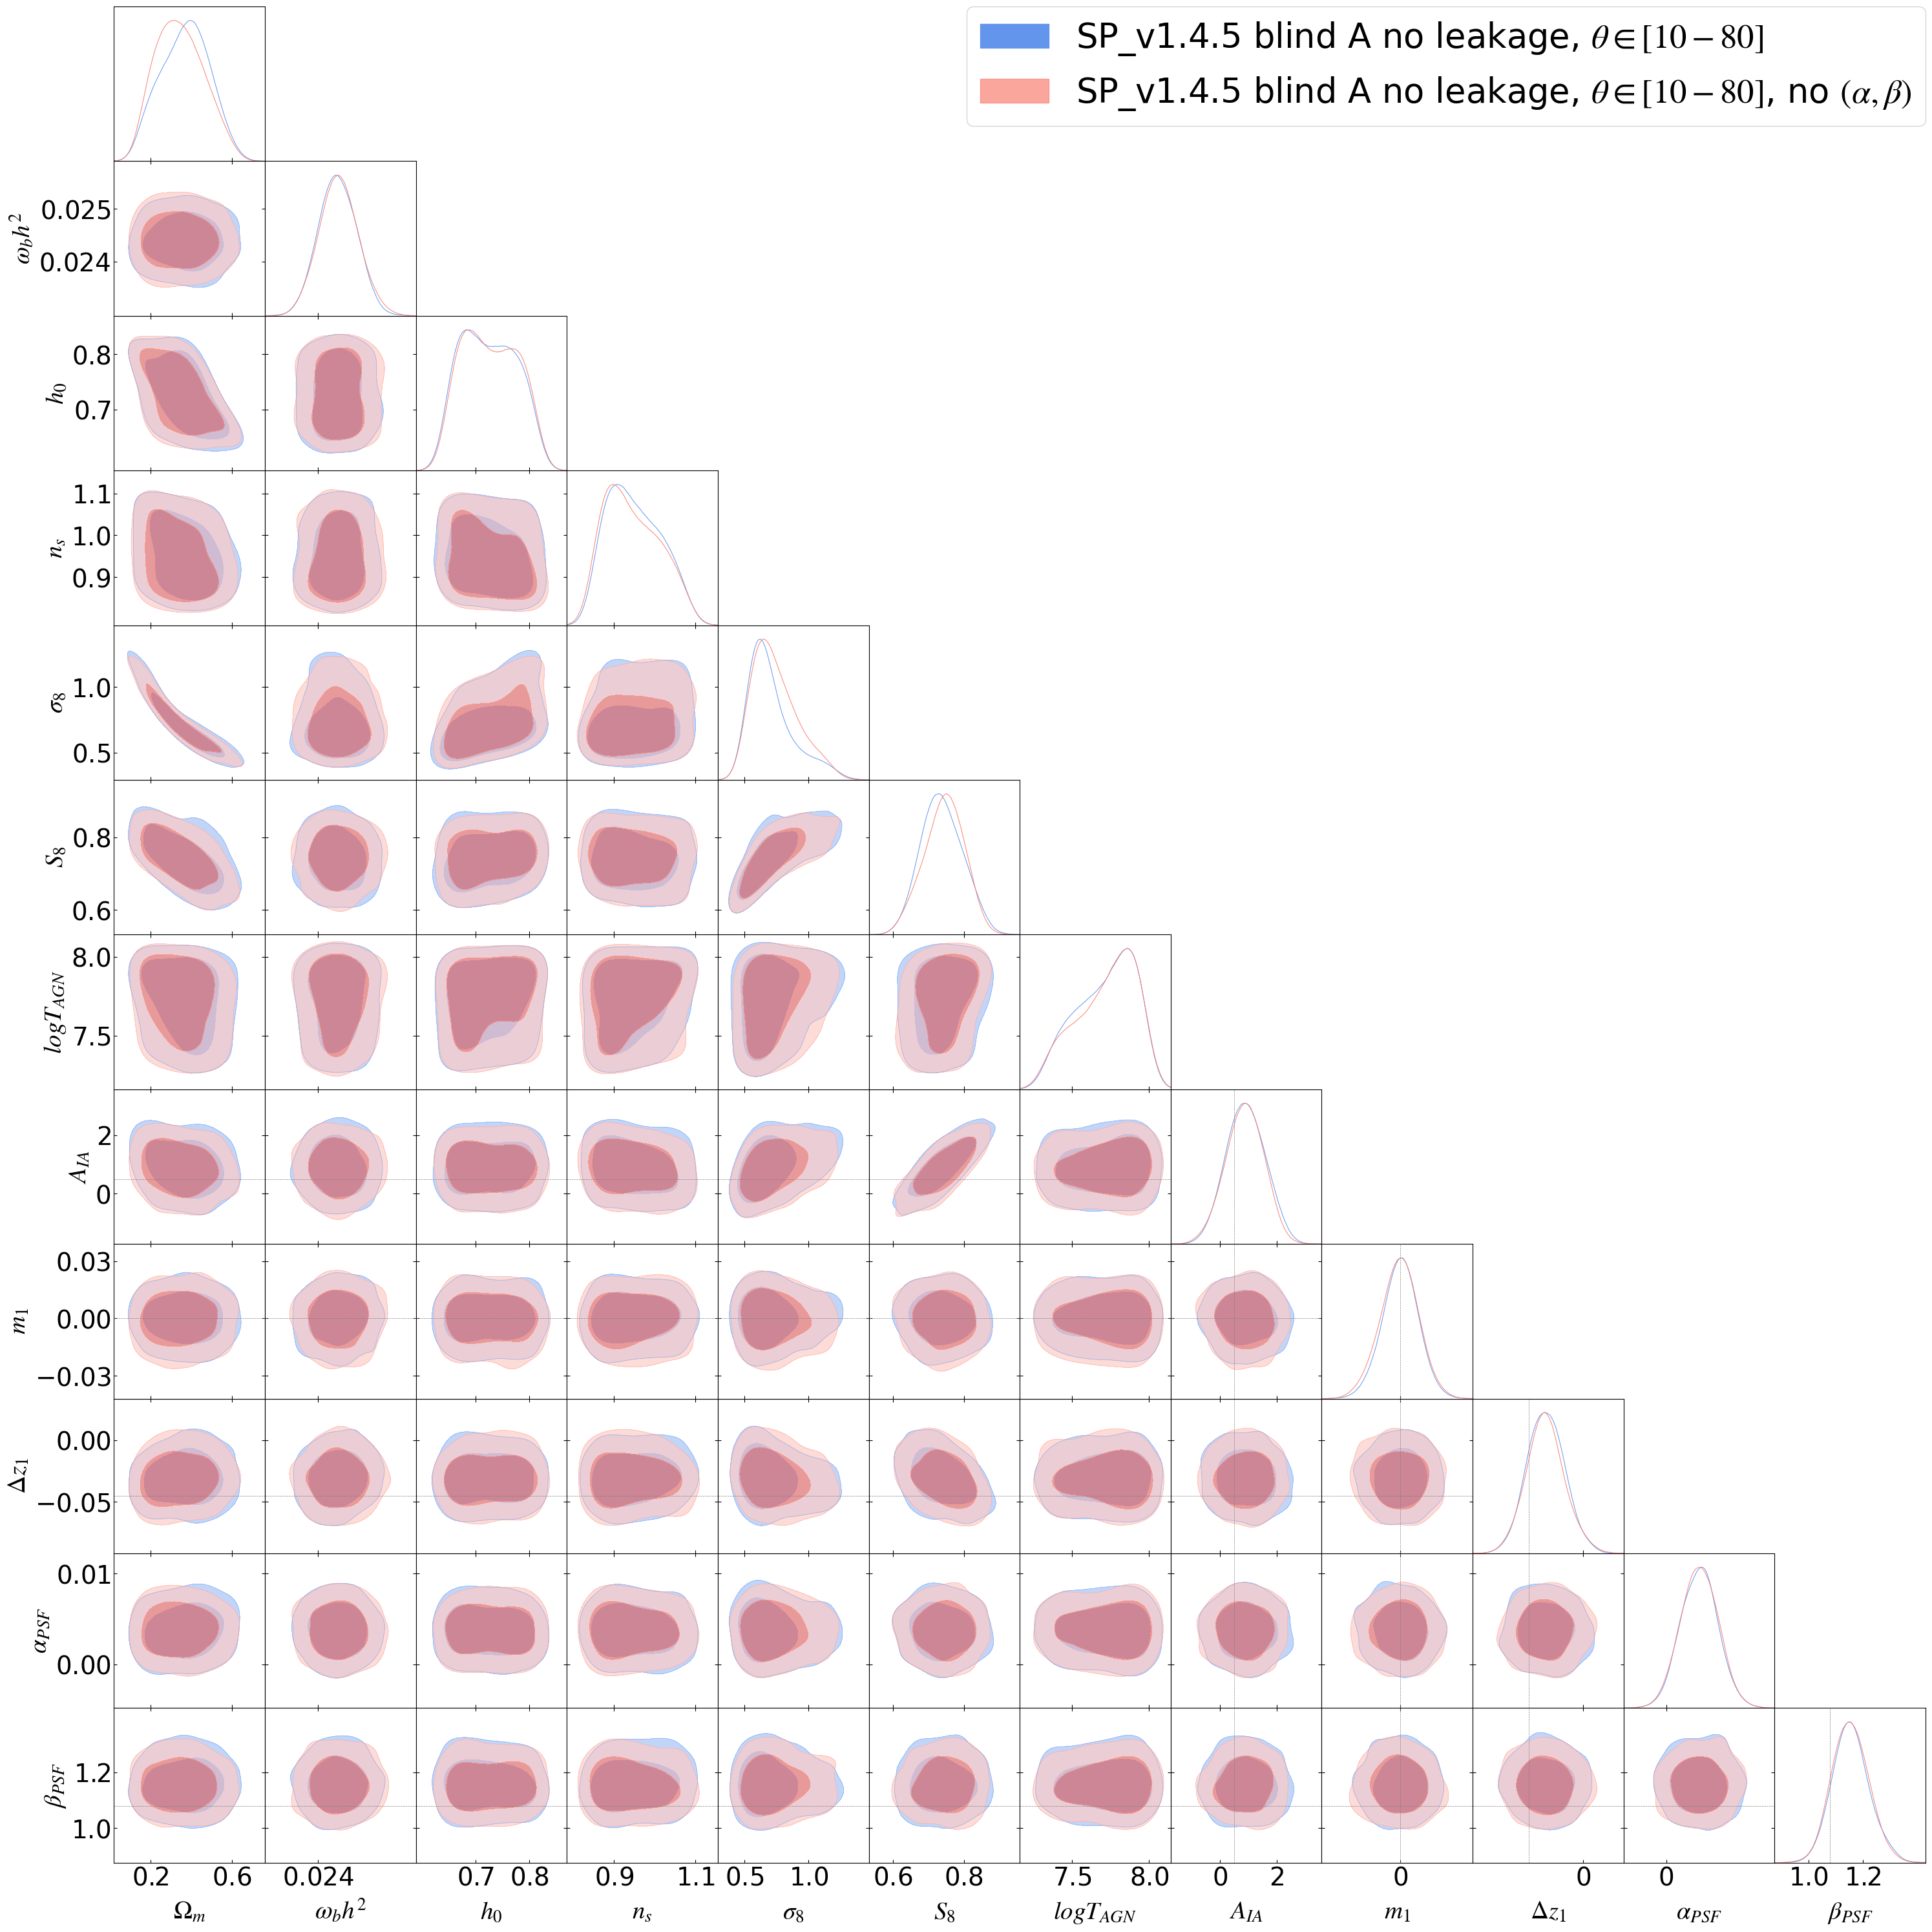

In [8]:
%matplotlib inline

""" legend_labels = [
    rf'$\theta \in$ [{lc}-{hc}]' for lc, hc in zip(lower_bound, upper_bound)
] """

legend_labels = [
    rf"GLASS mock {i}" for i in range(1, 17)
]

legend_labels = [
    "GLASS mock 1",
    "GLASS mock 1 takahashi",
    "GLASS mock 1 HM code"
]

legend_labels = [
    "SP_v1.4.5 blind A",
    #"SP_v1.4.5 blind A no IA",
    #r"SP_v1.4.5 blind A no $\Delta z$",
    #r"SP_v1.4.5 blind A no $m_1$",
    r"SP_v1.4.5 blind A, $\theta \in [3-150]$",
    r"SP_v1.4.5 blind A, $\theta \in [3-60]$",
    #r"SP_v1.4.5 blind A, $\theta \in [10-150]$",
    #r"SP_v1.4.5 blind A, $\theta \in [10-60]$",
    #r"SP_v1.4.5 blind A, $\theta \in [5-150]$",
    #r"SP_v1.4.5 blind A, $\theta \in [7-150]$",
    r"SP_v1.4.5 blind A no leakage",
    r"SP_v1.4.5 blind A no leakage, $\theta \in [3-150]$",
    r"SP_v1.4.5 blind A no leakage, $\theta \in [3-60]$",
]

legend_labels = [
    r"SP_v1.4.5 blind A no leakage,  $\theta \in [3-80]$",
    r"SP_v1.4.5 blind A no leakage, $\theta \in [5-180]$",
    r"SP_v1.4.5 blind A no leakage, $\theta \in [7-180]$",
    r"SP_v1.4.5 blind A no leakage, $\theta \in [10-80]$",
    r"SP_v1.4.5 blind A no leakage, $\theta \in [11-80]$",
]

legend_labels = [
    r"SP_v1.4.5 blind A no leakage, $\theta \in [10-80]$",
    r"SP_v1.4.5 blind A no leakage, $\theta \in [10-80]$, no $(\alpha, \beta)$",
]

contour_colors = [
    'cornflowerblue', 'salmon', 'darkorange', 'forestgreen', 'turquoise', 'darkviolet', 'crimson', 'gold', 'lightcoral', 'mediumseagreen', 'lightsteelblue', 'black', 'silver', 'peru', 'maroon', 'olive'
]

""" legend_labels = [
    r"GLASS mock 3",
    r"GLASS mock 3 no PSF",
    r"GLASS mock 3 no PSF baryons",
] """

marker = {
    'OMEGA_M': 0.3013160542257656,
    'ombh2': 0.024499999999999997,
    'omch2': 0.12249999999999998,
    'h0': 0.70,
    'n_s': 0.96,
    'SIGMA_8': 0.793897,
    's_8_input': 0.79563645,
    'm1': 0.0,
    'bias_1': 0.0,
    'alpha': -0.0005,
    'beta': 0.0631,
    'a': 0.0
}

marker = {
    'bias_1': -0.045,
    'm1': 0.0,
    'a': 0.5,
    'alpha': 0.0169,
    'beta': 1.0789
}
g.triangle_plot(chains,
                ['OMEGA_M','ombh2', 'h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1','alpha','beta'],
                legend_labels=legend_labels,
                legend_loc='upper right',
                # param_limits={'bias_1':[-0.8,0.5]},
                contour_colors=contour_colors,
                line_args=[{
                    'color': contour_colors[i],
                    'ls': 'solid'
                } for i in range(16)],
                # title_limit=1,
                filled=True,
                markers=marker)

g.export('contour_plot_unions_new_binning.png')

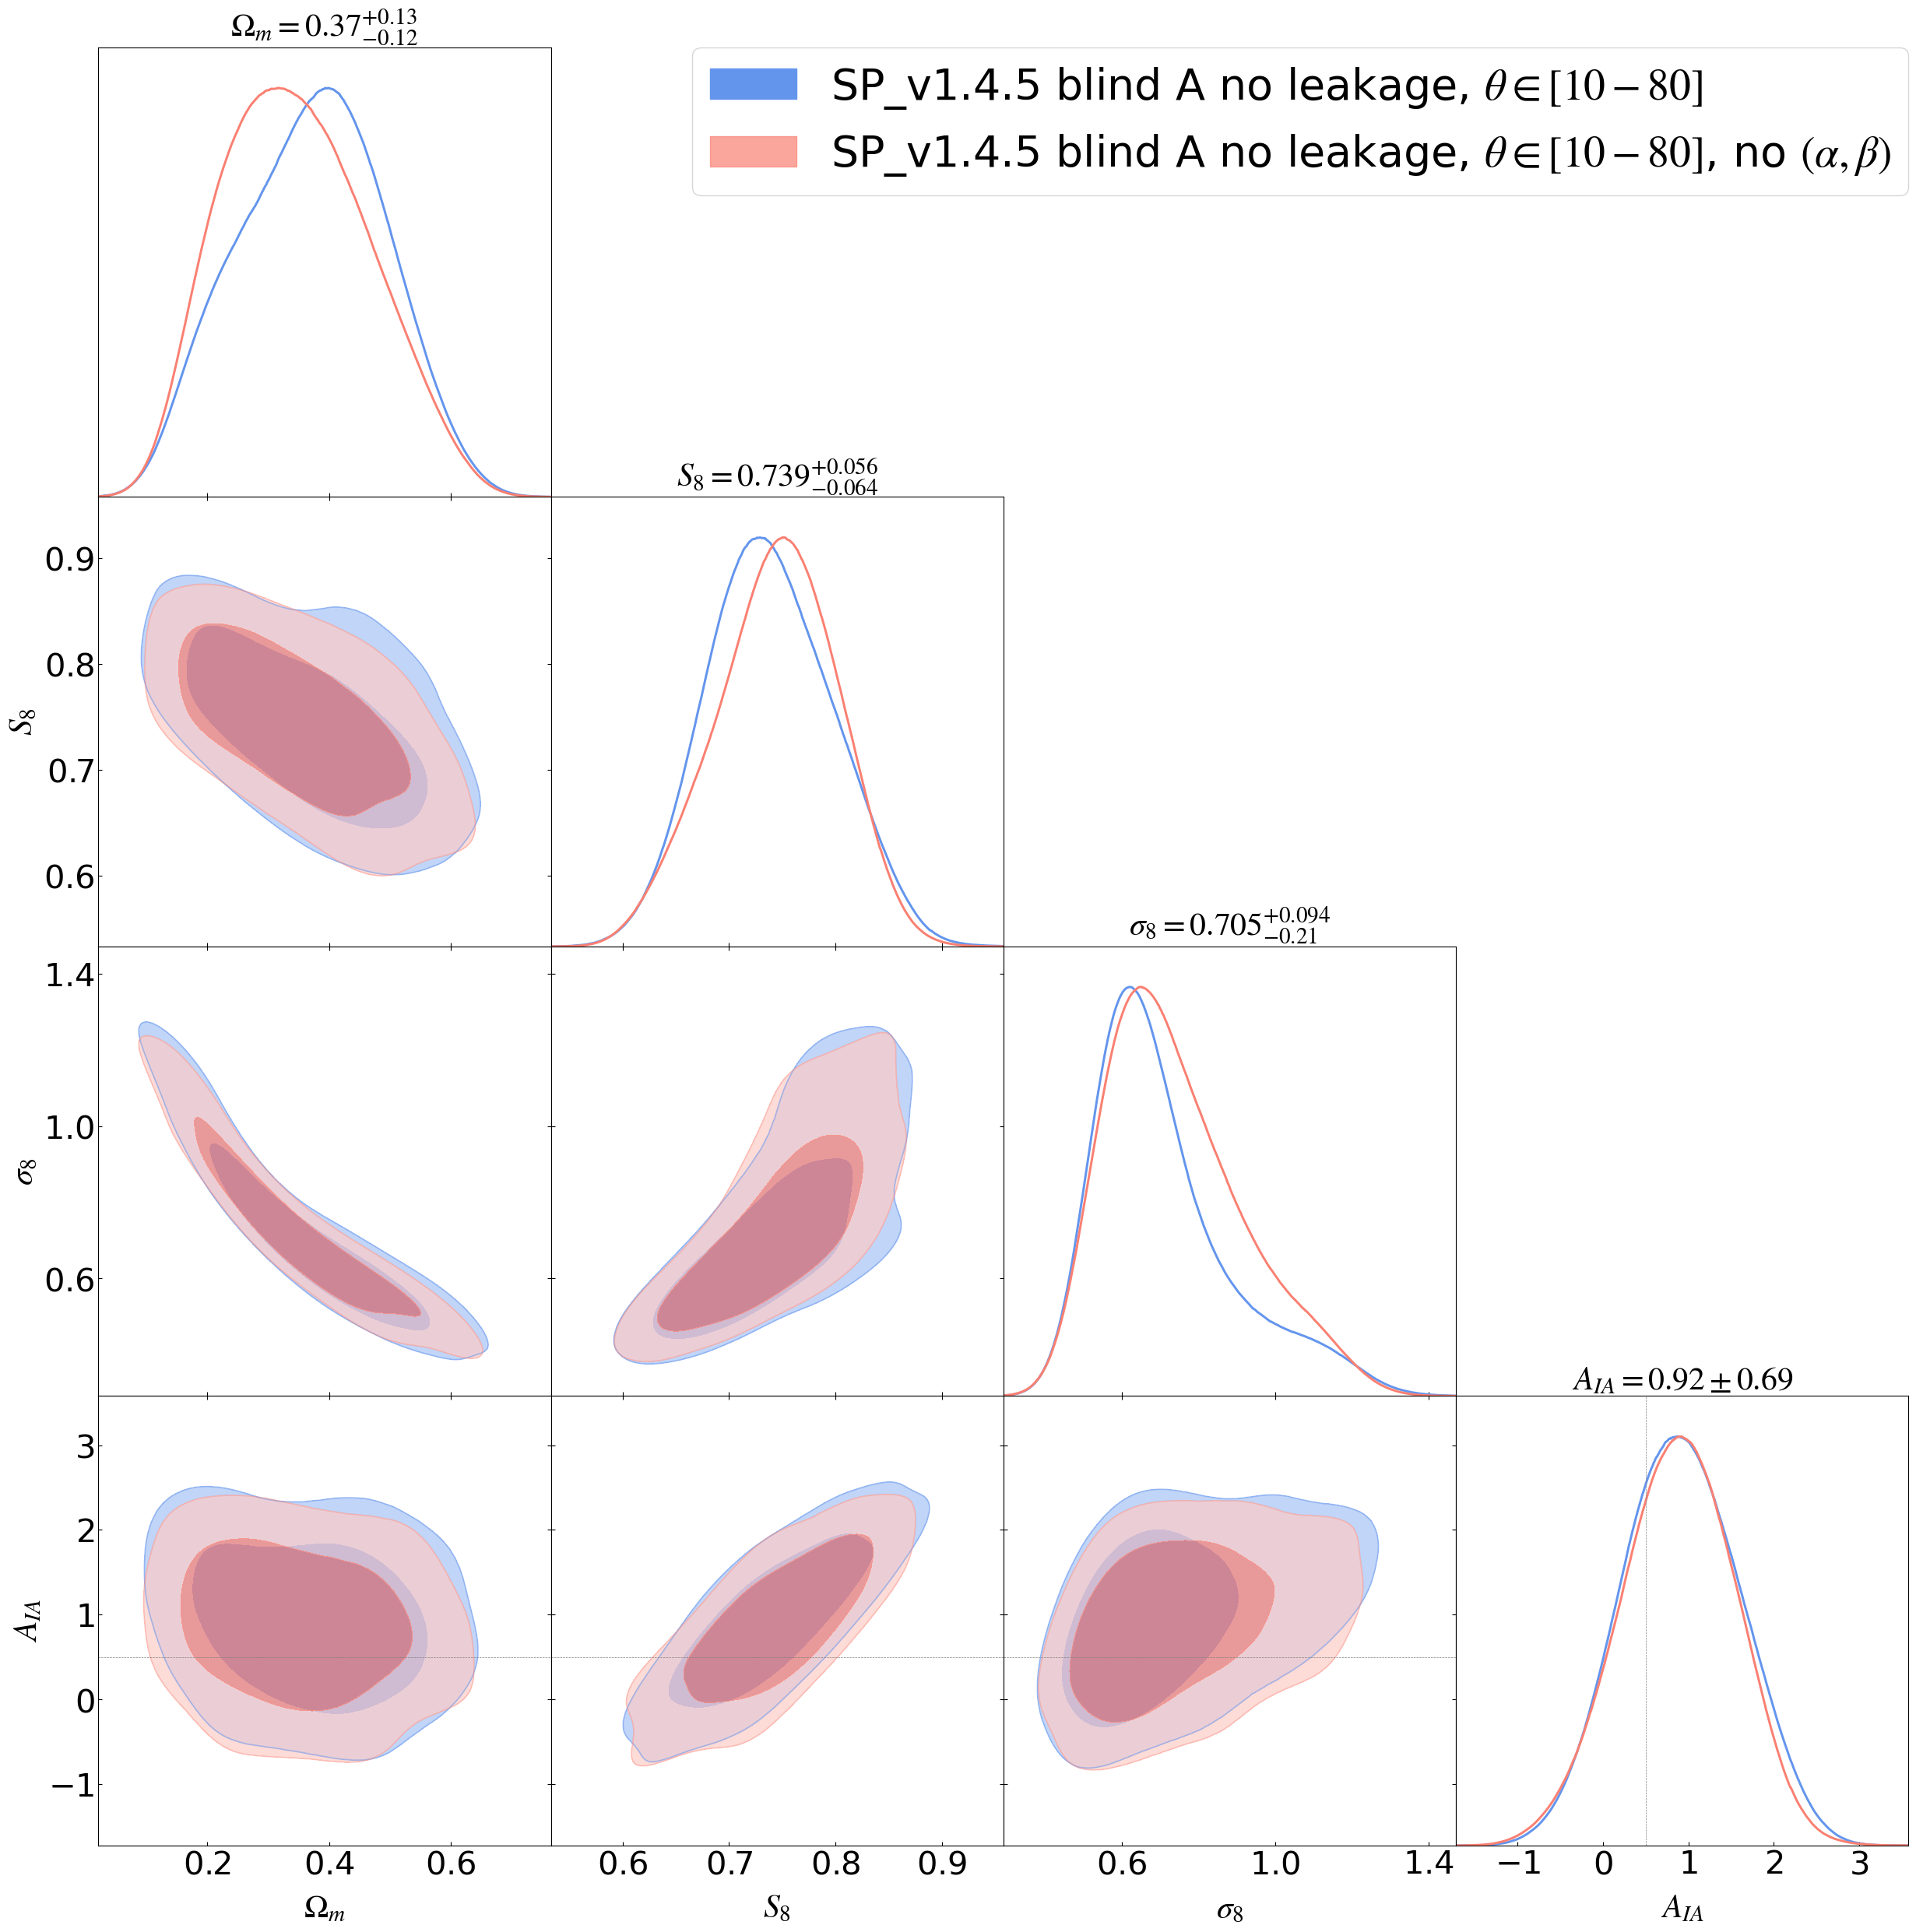

In [10]:
""" legend_labels = [
    rf'$\theta \in$ [{lc}-{hc}]' for lc, hc in zip(lower_bound, upper_bound)
] """
g.triangle_plot(chains,
                ['OMEGA_M', 's_8_input', 'SIGMA_8', 'a'],
                legend_labels=legend_labels,
                legend_loc='upper right',
                # param_limits={'bias_1':[-0.8,0.5]},
                contour_colors=contour_colors,
                line_args=[{
                    'color': contour_colors[i],
                    'ls': 'solid'
                } for i in range(16)],
                title_limit=1,
                filled=True,
                markers=marker)

g.export('contour_plot_s8_unions_w_wo_leakage.png')

### Output bestfit and sigma values

In [7]:
#########BESTFIT AND SIGMA VALS##########
params = ['OMEGA_M','omega_b','h0','n_s','a_s','SIGMA_8','S_8','logt_agn','a','m1', 'bias_1', 'alpha', 'beta', 'omch2', 'ombh2']
latex_params = [r'$\Omega_{\rm m,0}$',r'$\Omega_{\rm b,0}$',r'$h$',r'$n_{\rm s}$',r'$A_{\rm s}$',r'$\sigma_8$',r'$S_8$',
                r'$\log_{10}{T_{\rm AGN}}$',r'$\mathcal{A}_rm IA}$', r'$m_1$', r'$\Delta z$', r'$\alpha$', r'$\beta$', r'$\Omega_{\rm c,0}$', r'$\Omega_{\rm b,0}$']

for chain in chains:

    
    margestats = chain.getMargeStats()
    likestats = chain.getLikeStats()
    p=chain.getParams()

    for no in range(len(latex_params)):
        if hasattr(p,params[no]):
            param_stats = margestats.parWithName(params[no])
            a = np.array([param_stats.mean,param_stats.mean-param_stats.limits[0].lower, param_stats.limits[0].upper-param_stats.mean])
            if '%.2g' %a[1] == '%.2g' %a[2]:
                latex_params[no] += '&$%.3g\pm%.2g$'%(a[0],a[1])
            else:
                latex_params[no] += '&$%.3g_{-%.2g}^{+%.2g}$'%(a[0],a[1],a[2])
        else:
            latex_params[no] += '&$-$'

        
for param in latex_params:
    param += r'\\'
    print(param)   


$\Omega_{\rm m,0}$&$0.22_{-0.091}^{+0.039}$&$0.207_{-0.081}^{+0.035}$&$0.23_{-0.1}^{+0.043}$&$0.225_{-0.089}^{+0.043}$&$0.221_{-0.086}^{+0.041}$&$0.185_{-0.063}^{+0.027}$&$0.314_{-0.13}^{+0.077}$&$0.295_{-0.13}^{+0.078}$\\
$\Omega_{\rm b,0}$&$-$&$-$&$-$&$-$&$-$&$-$&$-$&$-$\\
$h$&$0.77_{-0.023}^{+0.049}$&$0.784_{-0.016}^{+0.037}$&$0.777_{-0.02}^{+0.044}$&$0.769_{-0.025}^{+0.051}$&$0.771_{-0.022}^{+0.048}$&$0.775_{-0.021}^{+0.044}$&$0.747_{-0.04}^{+0.065}$&$0.749_{-0.037}^{+0.063}$\\
$n_{\rm s}$&$1.04_{-0.031}^{+0.062}$&$1.05_{-0.023}^{+0.048}$&$1.04_{-0.028}^{+0.063}$&$1.03_{-0.032}^{+0.064}$&$1.04_{-0.03}^{+0.063}$&$1.03_{-0.032}^{+0.062}$&$1_{-0.048}^{+0.087}$&$1_{-0.048}^{+0.08}$\\
$A_{\rm s}$&$-$&$-$&$-$&$-$&$-$&$-$&$-$&$-$\\
$\sigma_8$&$1.06_{-0.15}^{+0.22}$&$1_{-0.13}^{+0.21}$&$0.959_{-0.14}^{+0.22}$&$1.04_{-0.15}^{+0.2}$&$1.05_{-0.15}^{+0.21}$&$1.14_{-0.12}^{+0.18}$&$0.8_{-0.21}^{+0.16}$&$0.843_{-0.23}^{+0.18}$\\
$S_8$&$0.867_{-0.048}^{+0.045}$&$0.799_{-0.021}^{+0.036}$&$0.798_{-

In [8]:
chain = chains[0]

margestats = chain.getMargeStats()
likestats = chain.getLikeStats()
p=chain.getParams()

for no in range(len(latex_params)):
        if hasattr(p,params[no]):
            param_stats = margestats.parWithName(params[no])
            a = np.array([param_stats.mean])
            print(params[no], a[0])

OMEGA_M 0.22043020450263065
h0 0.7703672811295145
n_s 1.037805666032269
SIGMA_8 1.0566235836296336
S_8 0.8670639815378972
logt_agn 7.663352117597701
a 1.2105355520872152
m1 -0.00196697175071132
bias_1 -0.05240296008081705
alpha 0.017313482956287624
beta 1.0863942321436328
omch2 0.1049656458902872
ombh2 0.024364520846452038


In [9]:
#########BESTFIT AND SIGMA VALS##########
params = ['OMEGA_M','omega_b','h0','n_s','a_s','SIGMA_8','S_8','logt_agn','a','m1', 'bias_1', 'alpha', 'beta', 'omch2', 'ombh2']
latex_params = [r'$\Omega_{\rm m,0}$',r'$\Omega_{\rm b,0}$',r'$h$',r'$n_{\rm s}$',r'$A_{\rm s}$',r'$\sigma_8$',r'$S_8$',
                r'$\log_{10}{T_{\rm AGN}}$',r'$\mathcal{A}_rm IA}$', r'$m_1$', r'$\Delta z$', r'$\alpha$', r'$\beta$', r'$\Omega_{\rm c,0}$', r'$\Omega_{\rm b,0}$']

values = {
    param: [] for param in params
}
for i, chain in enumerate(chains):

    
    margestats = chain.getMargeStats()
    likestats = chain.getLikeStats()
    p=chain.getParams()

    print(legend_labels[i])

    for param in params:
        if hasattr(p,param):
            param_stats = margestats.parWithName(param)
            a = np.array([param_stats.mean,param_stats.mean-param_stats.limits[0].lower, param_stats.limits[0].upper-param_stats.mean])
            print(f"{param}: {a[0]:.3g}_-{a[1]:.2g}^+{a[1]:.2g}")
            values[param].append(a[0])


SP_v1.4.5 blind A
OMEGA_M: 0.22_-0.091^+0.091
h0: 0.77_-0.023^+0.023
n_s: 1.04_-0.031^+0.031
SIGMA_8: 1.06_-0.15^+0.15
S_8: 0.867_-0.048^+0.048
logt_agn: 7.66_-0.2^+0.2
a: 1.21_-0.64^+0.64
m1: -0.00197_-0.01^+0.01
bias_1: -0.0524_-0.015^+0.015
alpha: 0.0173_-0.0025^+0.0025
beta: 1.09_-0.059^+0.059
omch2: 0.105_-0.049^+0.049
ombh2: 0.0244_-0.00038^+0.00038
SP_v1.4.5 blind A no IA
OMEGA_M: 0.207_-0.081^+0.081
h0: 0.784_-0.016^+0.016
n_s: 1.05_-0.023^+0.023
SIGMA_8: 1_-0.13^+0.13
S_8: 0.799_-0.021^+0.021
logt_agn: 7.63_-0.22^+0.22
a: 0.468_-0.74^+0.74
m1: -0.00187_-0.01^+0.01
bias_1: -0.0533_-0.015^+0.015
alpha: 0.0173_-0.0025^+0.0025
beta: 1.08_-0.057^+0.057
omch2: 0.101_-0.046^+0.046
ombh2: 0.0244_-0.00035^+0.00035
SP_v1.4.5 blind A no $\Delta z$
OMEGA_M: 0.23_-0.1^+0.1
h0: 0.777_-0.02^+0.02
n_s: 1.04_-0.028^+0.028
SIGMA_8: 0.959_-0.14^+0.14
S_8: 0.798_-0.029^+0.029
logt_agn: 7.62_-0.24^+0.24
a: 1.24_-0.59^+0.59
m1: -0.00158_-0.01^+0.01
bias_1: -0.0444_-0.016^+0.016
alpha: 0.0174_-0.002

In [19]:
bestfit_ix = np.argmax(chains[0].loglikes)
maxlike = chains[0].loglikes[bestfit_ix]
print(maxlike)

-53.07879009667595


In [20]:
chains[0].loglikes

array([-130.93739885, -129.69496447, -128.87659362, ...,  -53.1583345 ,
        -53.14464781,  -53.0787901 ])

In [21]:
print(chains[0].likeStats)

Best fit sample -log(Like) = -130.937399
mean(-Ln(like)) = -56.494838
-Ln(mean like)  = -61.654549
2*Var(Ln(like)) = 6.826970

parameter      bestfit        lower1         upper1         lower2         upper2
omch2          2.2612241E-01  5.1101085E-02  2.5479458E-01  5.1101085E-02  2.5479458E-01   
h0             6.7212702E-01  6.4020469E-01  8.1995639E-01  6.4020469E-01  8.1995639E-01   h_0
ombh2          2.4768577E-02  2.3192533E-02  2.5780490E-02  2.3096439E-02  2.5780490E-02   \omega_b h^2
n_s            9.2884726E-01  8.4033874E-01  1.0999498E+00  8.4033874E-01  1.0999498E+00   n_s
s_8_input      6.1809209E-01  5.1292536E-01  1.0328900E+00  5.1292536E-01  1.0328900E+00   S_8
logt_agn       7.5804395E+00  7.3002047E+00  7.9998693E+00  7.3002047E+00  7.9998693E+00   log T_{AGN}
a              4.0156497E-01 -1.4296039E+00  2.7608967E+00 -1.4296039E+00  2.8983769E+00   A_{IA}
m1            -1.0116411E-02 -3.2167059E-02  2.9555065E-02 -3.2167059E-02  3.4115696E-02   m_1
bias_1        

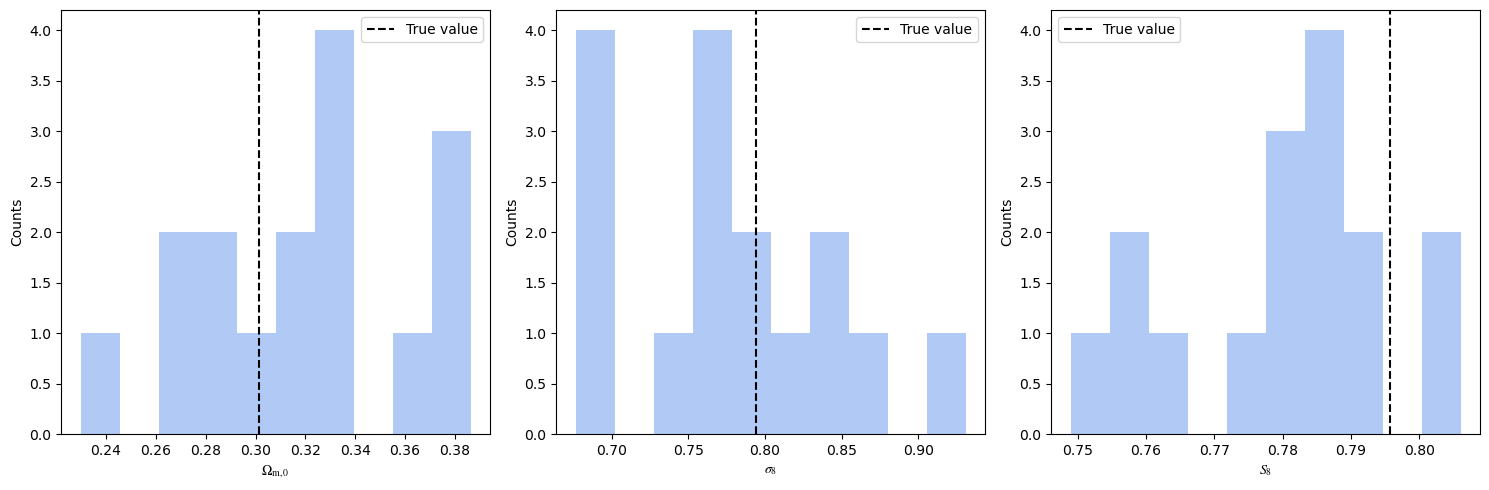

In [22]:
plt.figure(figsize=(15, 5))

plt.subplot(131)

plt.hist(values['OMEGA_M'], bins=10, color='cornflowerblue', alpha=0.5)
plt.axvline(0.301316, color='black', linestyle='--', label='True value')
plt.xlabel(r'$\Omega_{\rm m,0}$')
plt.ylabel('Counts')
plt.legend()

plt.subplot(132)

plt.hist(values['SIGMA_8'], bins=10, color='cornflowerblue', alpha=0.5)
plt.axvline(0.793897, color='black', linestyle='--', label='True value')
plt.xlabel(r'$\sigma_8$')
plt.ylabel('Counts')
plt.legend()

plt.subplot(133)

plt.hist(values['S_8'], bins=10, color='cornflowerblue', alpha=0.5)
plt.axvline(0.79563645, color='black', linestyle='--', label='True value')
plt.xlabel(r'$S_8$')
plt.ylabel('Counts')
plt.legend()
plt.tight_layout()

plt.show()

In [26]:
np.sum(np.abs(np.array(values['S_8']) - 0.79563645) < 0.03)/len(values['S_8'])

0.75

## Looking at best fit

In [4]:
from astropy.io import fits

version = 'SP_v1.4.5_glass_mock_1'

data = fits.open(f'/home/guerrini/sp_validation/cosmo_inference/data/{version}/cosmosis_{version}.fits')
xi_plus = data['XI_PLUS'].data
xi_minus = data['XI_MINUS'].data
cov_mat = data['COVMAT'].data

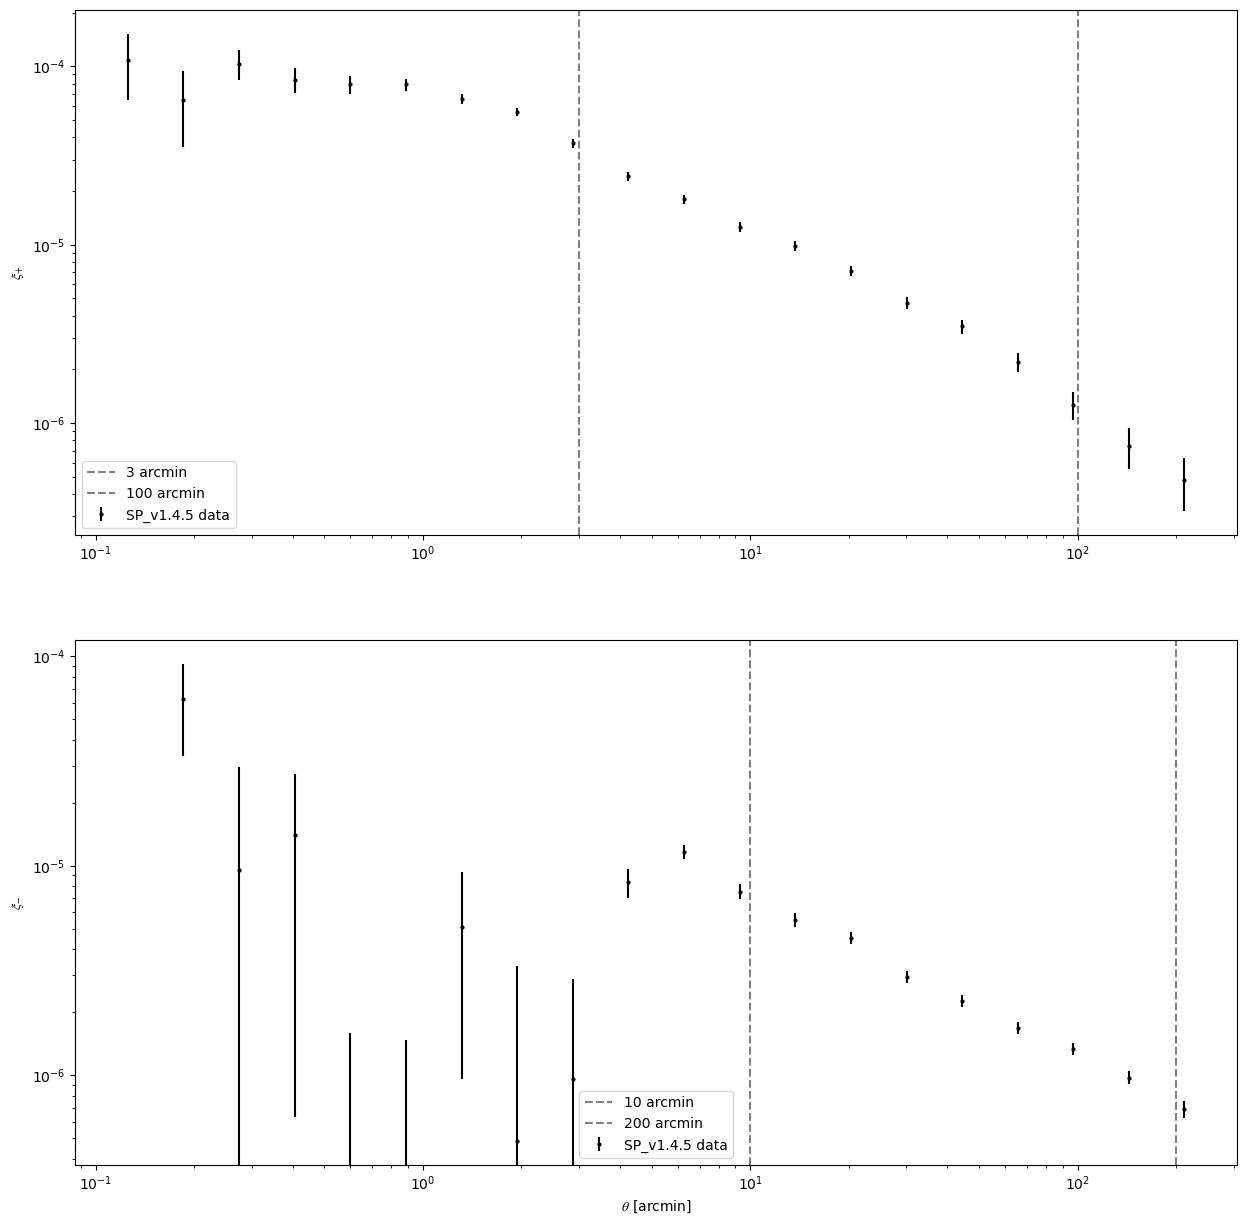

In [11]:
plt.figure(figsize=(15, 15))

plt.subplot(211)

plt.errorbar(xi_plus['ANG'], xi_plus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[:20], fmt='o', label='SP_v1.4.5 data', color='black', markersize=2)

plt.ylabel(r'$\xi_{+}$')
plt.xscale('log')
plt.yscale('log')
plt.axvline(3.0, color='grey', linestyle='--', label='3 arcmin')
plt.axvline(100.0, color='grey', linestyle='--', label='100 arcmin')
plt.legend()

plt.subplot(212)

plt.errorbar(xi_minus['ANG'], xi_minus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[20:40], fmt='o', label='SP_v1.4.5 data', color='black', markersize=2)

plt.xlabel(r'$\theta$ [arcmin]')
plt.ylabel(r'$\xi_{-}$')
plt.xscale('log')
plt.yscale('log')
plt.axvline(10.0, color='grey', linestyle='--', label='10 arcmin')
plt.axvline(200.0, color='grey', linestyle='--', label='200 arcmin')
plt.legend()

plt.savefig('xi_data.png')

plt.show()

In [12]:
import pyccl as ccl

#Get theory correlation function from CCL
#Define the cosmology
theta_arcmin = np.logspace(np.log10(0.1), np.log10(250), 1000)
h = 0.7
Oc = 0.25
Ob = 0.05
sigma8 = 0.793897
n_s = 0.96
cosmo = ccl.Cosmology(
    h=h,
    Omega_c = Oc,
    Omega_b = Ob,
    sigma8 = sigma8,
    n_s = n_s,
    transfer_function='boltzmann_camb',
)

#Define the redshift distribution
z, dndz = np.loadtxt('/home/guerrini/sp_validation/cosmo_inference/cosmocov_config/dndz_test.txt', unpack=True)

tracer = ccl.WeakLensingTracer(cosmo, dndz=(z, dndz), ia_bias=None)

#COmpute the angular power spectrum C_ell
ell = np.logspace(0, np.log10(10000), 2000)
cl_gg = ccl.angular_cl(cosmo, tracer, tracer, ell)

#Compute the 2PCF
theta_deg = theta_arcmin / 60
#xi+ fit
xi_p_theta_true = ccl.correlation(cosmo, ell=ell, C_ell=cl_gg, theta=theta_deg, type='GG+')
#xi- fit
xi_m_theta_true = ccl.correlation(cosmo, ell=ell, C_ell=cl_gg, theta=theta_deg, type='GG-')

/home/guerrini/.conda/envs/sp_validation/lib/python3.9/site-packages/pyccl/tracers.py:110: CCLWarning: The number of samples in the n(z) (201) is smaller than the number of samples in the lensing kernel (256). Consider disabling spline integration for the lensing kernel by setting pyccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False
  warnings.warn(


In [47]:
#Get theory correlation function from CCL
#Define the cosmology
theta_arcmin = np.logspace(np.log10(0.1), np.log10(250), 1000)
h = 0.6982064176424748
Oc = 0.21522128974860827/h**2
print("Omega_c:", Oc)
Ob = 0.024410205304489712/h**2
print("Omega_b:", Ob)
sigma8 = 0.5330533925822226
print("S8:", sigma8*np.sqrt((Oc+Ob)/0.3))
n_s = 0.9867762122563981
a_ia = 0.0
cosmo = ccl.Cosmology(
    h=h,
    Omega_c = Oc,
    Omega_b = Ob,
    sigma8 = sigma8,
    n_s = n_s,
    transfer_function='boltzmann_camb',
)

#Define the redshift distribution
z, dndz = np.loadtxt('/home/guerrini/sp_validation/cosmo_inference/cosmocov_config/dndz_test.txt', unpack=True)

tracer = ccl.WeakLensingTracer(cosmo, dndz=(z, dndz), ia_bias=(z, np.ones_like(z)*a_ia))

#COmpute the angular power spectrum C_ell
ell = np.logspace(0, np.log10(10000), 2000)
cl_gg = ccl.angular_cl(cosmo, tracer, tracer, ell)

#Compute the 2PCF
theta_deg = theta_arcmin / 60
#xi+ fit
xi_p_theta_fit = ccl.correlation(cosmo, ell=ell, C_ell=cl_gg, theta=theta_deg, type='GG+')
#xi- fit
xi_m_theta_fit = ccl.correlation(cosmo, ell=ell, C_ell=cl_gg, theta=theta_deg, type='GG-')

Omega_c: 0.44148663101857577
Omega_b: 0.05007301700932502
S8: 0.6823358608510779


/home/guerrini/.conda/envs/sp_validation/lib/python3.9/site-packages/pyccl/tracers.py:110: CCLWarning: The number of samples in the n(z) (201) is smaller than the number of samples in the lensing kernel (256). Consider disabling spline integration for the lensing kernel by setting pyccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False
  warnings.warn(


In [57]:
#Get theory correlation function from CCL
#Define the cosmology
theta_arcmin = np.logspace(np.log10(0.1), np.log10(250), 1000)
h = 0.6982064176424748
Oc = 0.21522128974860827/h**2
print("Omega_c:", Oc)
Ob = 0.024410205304489712/h**2
print("Omega_b:", Ob)
sigma8 = 0.5330533925822226
print("S8:", sigma8*np.sqrt((Oc+Ob)/0.3))
n_s = 0.9867762122563981
a_ia = -0.4225120529551343
cosmo = ccl.Cosmology(
    h=h,
    Omega_c = Oc,
    Omega_b = Ob,
    sigma8 = sigma8,
    n_s = n_s,
    transfer_function='boltzmann_camb',
)

#Define the redshift distribution
z, dndz = np.loadtxt('/home/guerrini/sp_validation/cosmo_inference/cosmocov_config/dndz_test.txt', unpack=True)

tracer = ccl.WeakLensingTracer(cosmo, dndz=(z, dndz), ia_bias=(z, np.ones_like(z)*a_ia))

#COmpute the angular power spectrum C_ell
ell = np.logspace(0, np.log10(10000), 2000)
cl_gg = ccl.angular_cl(cosmo, tracer, tracer, ell)

#Compute the 2PCF
theta_deg = theta_arcmin / 60
#xi+ fit
xi_p_theta_fit_IA = ccl.correlation(cosmo, ell=ell, C_ell=cl_gg, theta=theta_deg, type='GG+')
#xi- fit
xi_m_theta_fit_IA = ccl.correlation(cosmo, ell=ell, C_ell=cl_gg, theta=theta_deg, type='GG-')

Omega_c: 0.44148663101857577
Omega_b: 0.05007301700932502
S8: 0.6823358608510779


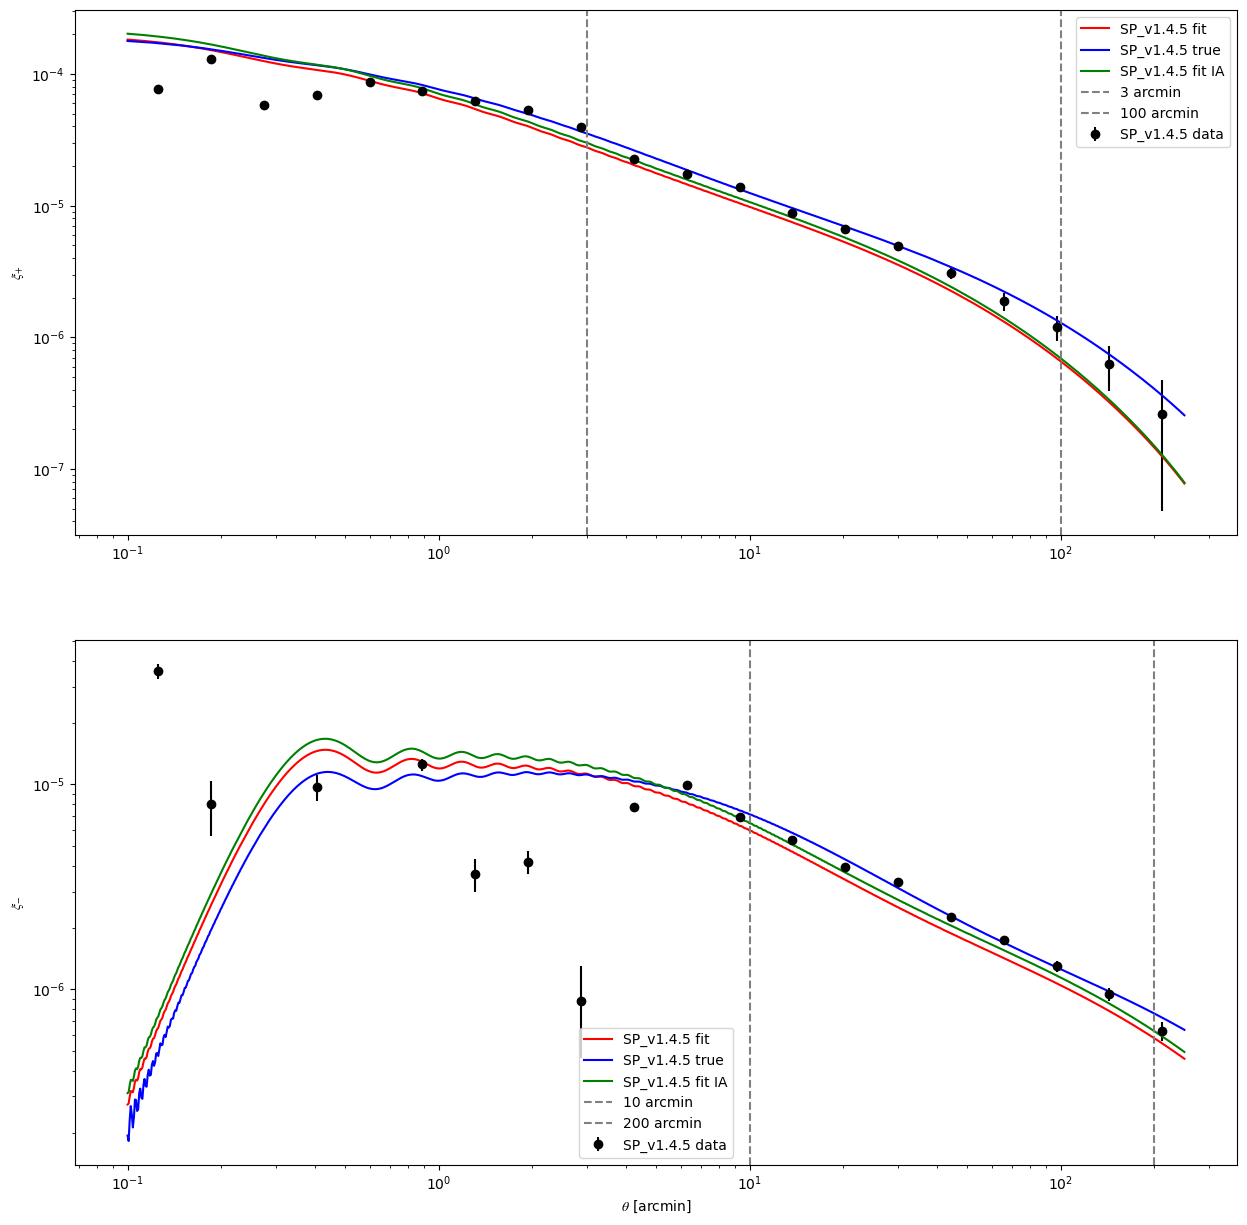

In [58]:
plt.figure(figsize=(15, 15))

plt.subplot(211)

plt.errorbar(xi_plus['ANG'], xi_plus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[:20], fmt='o', label='SP_v1.4.5 data', color='black')
plt.plot(theta_arcmin, xi_p_theta_fit, label='SP_v1.4.5 fit', color='red')
plt.plot(theta_arcmin, xi_p_theta_true, label='SP_v1.4.5 true', color='blue')
plt.plot(theta_arcmin, xi_p_theta_fit_IA, label='SP_v1.4.5 fit IA', color='green')

plt.ylabel(r'$\xi_{+}$')
plt.xscale('log')
plt.yscale('log')
plt.axvline(3.0, color='grey', linestyle='--', label='3 arcmin')
plt.axvline(100.0, color='grey', linestyle='--', label='100 arcmin')
plt.legend()

plt.subplot(212)

plt.errorbar(xi_minus['ANG'], xi_minus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[20:40], fmt='o', label='SP_v1.4.5 data', color='black')
plt.plot(theta_arcmin, xi_m_theta_fit, label='SP_v1.4.5 fit', color='red')
plt.plot(theta_arcmin, xi_m_theta_true, label='SP_v1.4.5 true', color='blue')
plt.plot(theta_arcmin, xi_m_theta_fit_IA, label='SP_v1.4.5 fit IA', color='green')

plt.xlabel(r'$\theta$ [arcmin]')
plt.ylabel(r'$\xi_{-}$')
plt.xscale('log')
plt.yscale('log')
plt.axvline(10.0, color='grey', linestyle='--', label='10 arcmin')
plt.axvline(200.0, color='grey', linestyle='--', label='200 arcmin')
plt.legend()

plt.show()

In [13]:
#Add best-fit model
root_dir = '/n09data/guerrini/output_chains/output_result/glass_mock_1/'
xi_plus_bf_no_psf = np.loadtxt(root_dir+'best_fit/shear_xi_plus/bin_1_1.txt')
xi_minus_bf_no_psf = np.loadtxt(root_dir+'best_fit/shear_xi_minus/bin_1_1.txt')
xi_sys_p = np.loadtxt(root_dir+'best_fit/xi_sys/shear_xi_plus.txt')
xi_sys_m = np.loadtxt(root_dir+'best_fit/xi_sys/shear_xi_minus.txt')
theta_xi_sys = np.loadtxt(root_dir+'best_fit/xi_sys/theta.txt')
theta_xi_sys = theta_xi_sys * 180*60/np.pi
angle = np.loadtxt(root_dir+'best_fit/shear_xi_plus/theta.txt')
angle = angle * 180*60/np.pi

mask = (angle < 250) & (angle > 0.1)

from scipy.interpolate import interp1d

xi_sys_p_interp = interp1d(theta_xi_sys, xi_sys_p, kind='linear', fill_value='extrapolate')
xi_sys_m_interp = interp1d(theta_xi_sys, xi_sys_m, kind='linear', fill_value='extrapolate')
xi_plus_bf = xi_plus_bf_no_psf[mask] + xi_sys_p_interp(angle[mask])
xi_minus_bf = xi_minus_bf_no_psf[mask] + xi_sys_m_interp(angle[mask])

xi_plus_bf_no_baryons = np.loadtxt(root_dir+'best_fit_no_feedback/shear_xi_plus/bin_1_1.txt')
xi_minus_bf_no_baryons = np.loadtxt(root_dir+'best_fit_no_feedback/shear_xi_minus/bin_1_1.txt')

xi_plus_bf_no_IA = np.loadtxt(root_dir+'best_fit_no_IA/shear_xi_plus/bin_1_1.txt')
xi_minus_bf_no_IA = np.loadtxt(root_dir+'best_fit_no_IA/shear_xi_minus/bin_1_1.txt')

xi_plus_truth_cosmosis = np.loadtxt(root_dir+'/truth/shear_xi_plus/bin_1_1.txt')
xi_minus_truth_cosmosis = np.loadtxt(root_dir+'/truth/shear_xi_minus/bin_1_1.txt')

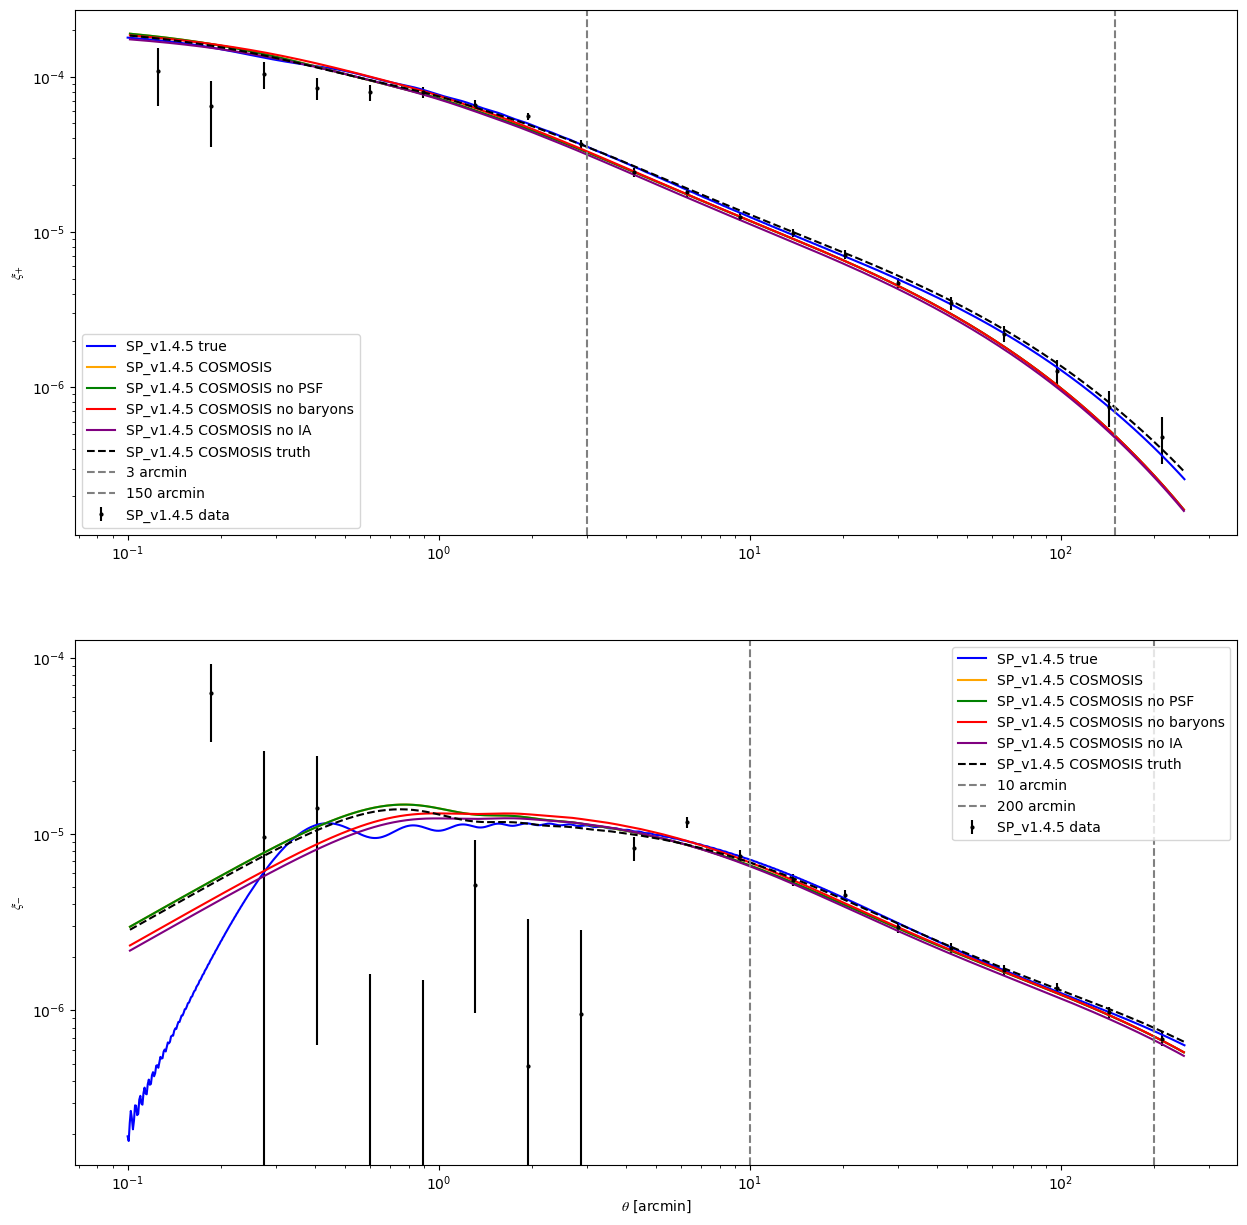

In [14]:
plt.figure(figsize=(15, 15))

plt.subplot(211)

plt.errorbar(xi_plus['ANG'], xi_plus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[:20], fmt='o', label='SP_v1.4.5 data', color='black', markersize=2)
plt.plot(theta_arcmin, xi_p_theta_true, label='SP_v1.4.5 true', color='blue')
plt.plot(angle[mask], xi_plus_bf, label='SP_v1.4.5 COSMOSIS', color='orange')
plt.plot(angle[mask], xi_plus_bf_no_psf[mask], label='SP_v1.4.5 COSMOSIS no PSF', color='green')
plt.plot(angle[mask], xi_plus_bf_no_baryons[mask], label='SP_v1.4.5 COSMOSIS no baryons', color='red')
plt.plot(angle[mask], xi_plus_bf_no_IA[mask], label='SP_v1.4.5 COSMOSIS no IA', color='purple')
plt.plot(angle[mask], xi_plus_truth_cosmosis[mask], label='SP_v1.4.5 COSMOSIS truth', color='black', linestyle='--')

plt.ylabel(r'$\xi_{+}$')
plt.xscale('log')
plt.yscale('log')
plt.axvline(3.0, color='grey', linestyle='--', label='3 arcmin')
plt.axvline(150.0, color='grey', linestyle='--', label='150 arcmin')
plt.legend()

plt.subplot(212)

plt.errorbar(xi_minus['ANG'], xi_minus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[20:40], fmt='o', label='SP_v1.4.5 data', color='black', markersize=2)
plt.plot(theta_arcmin, xi_m_theta_true, label='SP_v1.4.5 true', color='blue')
plt.plot(angle[mask], xi_minus_bf, label='SP_v1.4.5 COSMOSIS', color='orange')
plt.plot(angle[mask], xi_minus_bf_no_psf[mask], label='SP_v1.4.5 COSMOSIS no PSF', color='green')
plt.plot(angle[mask], xi_minus_bf_no_baryons[mask], label='SP_v1.4.5 COSMOSIS no baryons', color='red')
plt.plot(angle[mask], xi_minus_bf_no_IA[mask], label='SP_v1.4.5 COSMOSIS no IA', color='purple')
plt.plot(angle[mask], xi_minus_truth_cosmosis[mask], label='SP_v1.4.5 COSMOSIS truth', color='black', linestyle='--')

plt.xlabel(r'$\theta$ [arcmin]')
plt.ylabel(r'$\xi_{-}$')
plt.xscale('log')
plt.yscale('log')
plt.axvline(10.0, color='grey', linestyle='--', label='10 arcmin')
plt.axvline(200.0, color='grey', linestyle='--', label='200 arcmin')
plt.legend()

plt.show()

In [14]:
import treecorr

theta_min = 0.1
theta_max = 250.0
nbins = 20
var_method = 'jackknife'

treecorr_config = {
            "ra_units": "degrees",
            "dec_units": "degrees",
            "min_sep": theta_min,
            "max_sep": theta_max,
            "sep_units": "arcmin",
            "nbins": nbins,
            "var_method": var_method,
        }

gg = treecorr.GGCorrelation(treecorr_config)

#Load the measurement
cat = fits.getdata(f'/n09data/guerrini/glass_mock/results/unions_glass_sim_00001_4096.fits')

e1 = cat['e1']
e2 = cat['e2']
ra = cat['ra']
dec = cat['dec']

#Create the catalog
cat = treecorr.Catalog(ra=ra, dec=dec, ra_units='degrees', dec_units='degrees', g1=e1, g2=e2, npatch=200)

#Process the catalog
gg.process(cat)



In [15]:
cov = treecorr.estimate_multi_cov([gg], method='jackknife')

In [16]:
data_vector_sim = []

for ver in [f'SP_v1.4.5_glass_mock_{i}' for i in range(1, 17)]:
    data = fits.open(f'/home/guerrini/sp_validation/cosmo_inference/data/{ver}/cosmosis_{ver}.fits')
    xi_plus = data['XI_PLUS'].data
    xi_minus = data['XI_MINUS'].data
    data_vector_sim.append(np.concatenate((xi_plus['VALUE'], xi_minus['VALUE'])))

data_vector_sim = np.array(data_vector_sim)

data_vector_sim.shape

(16, 40)

In [17]:
cov_sim = np.cov(data_vector_sim.T)

In [19]:
ver_sacha = 'SP_v1.4.5'

cov_th_sacha = np.loadtxt('/home/guerrini/sp_validation/cosmo_inference/data/{}/covs/cov_{}.txt'.format(ver_sacha, ver_sacha))

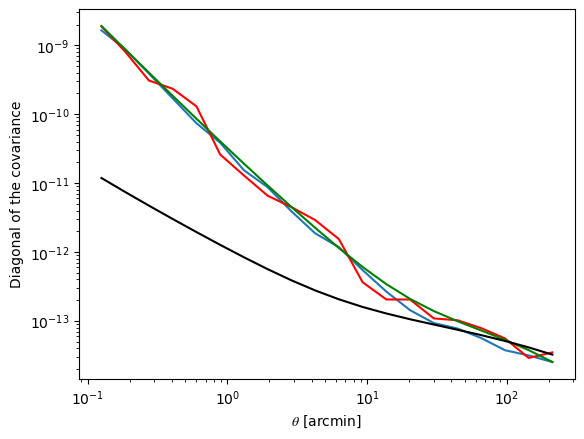

In [21]:
plt.figure()

plt.plot(xi_plus['ANG'], np.diag(cov)[:20])
plt.plot(xi_plus['ANG'], np.diag(cov_sim)[:20], label='SP_v1.4.5 data', color='red')
plt.plot(xi_plus['ANG'], np.diag(cov_th_sacha)[:20], label='SP_v1.4.5 data', color='green')
plt.plot(xi_plus['ANG'], np.diag(cov_mat)[:20], label='SP_v1.4.5 data', color='black')

plt.ylabel('Diagonal of the covariance')
plt.xlabel(r'$\theta$ [arcmin]')

plt.yscale('log')
plt.xscale('log')
plt.savefig('check_cov.png')
plt.show()

In [21]:
gg.varxip

array([1.68731981e-09, 8.23198541e-10, 3.72104580e-10, 1.81009312e-10,
       7.55205593e-11, 3.70850594e-11, 1.58407100e-11, 8.79188955e-12,
       4.83950781e-12, 2.07109650e-12, 1.18914903e-12, 4.42672727e-13,
       3.20013101e-13, 1.51953339e-13, 8.79416720e-14, 7.60782379e-14,
       5.66727563e-14, 4.00609306e-14, 3.10548392e-14, 2.90309607e-14])

In [20]:
np.sqrt(gg.varxip)

array([4.3623e-05, 2.4672e-05, 2.0750e-05, 1.1523e-05, 8.4231e-06,
       6.3445e-06, 3.9045e-06, 3.1742e-06, 2.0859e-06, 1.4487e-06,
       1.1033e-06, 7.0394e-07, 5.1740e-07, 3.7520e-07, 3.1344e-07,
       2.8632e-07, 2.4588e-07, 1.8443e-07, 1.7310e-07, 1.5879e-07])

In [21]:
np.sqrt(np.diag(cov_mat)[0:20])

array([3.44384146e-06, 2.72665839e-06, 2.17087632e-06, 1.73671506e-06,
       1.39571577e-06, 1.12709174e-06, 9.15663257e-07, 7.50618745e-07,
       6.23133132e-07, 5.26321508e-07, 4.53666122e-07, 3.99183817e-07,
       3.57926473e-07, 3.25021676e-07, 2.97594892e-07, 2.72727034e-07,
       2.49288074e-07, 2.26122847e-07, 2.03060944e-07, 1.80000581e-07])

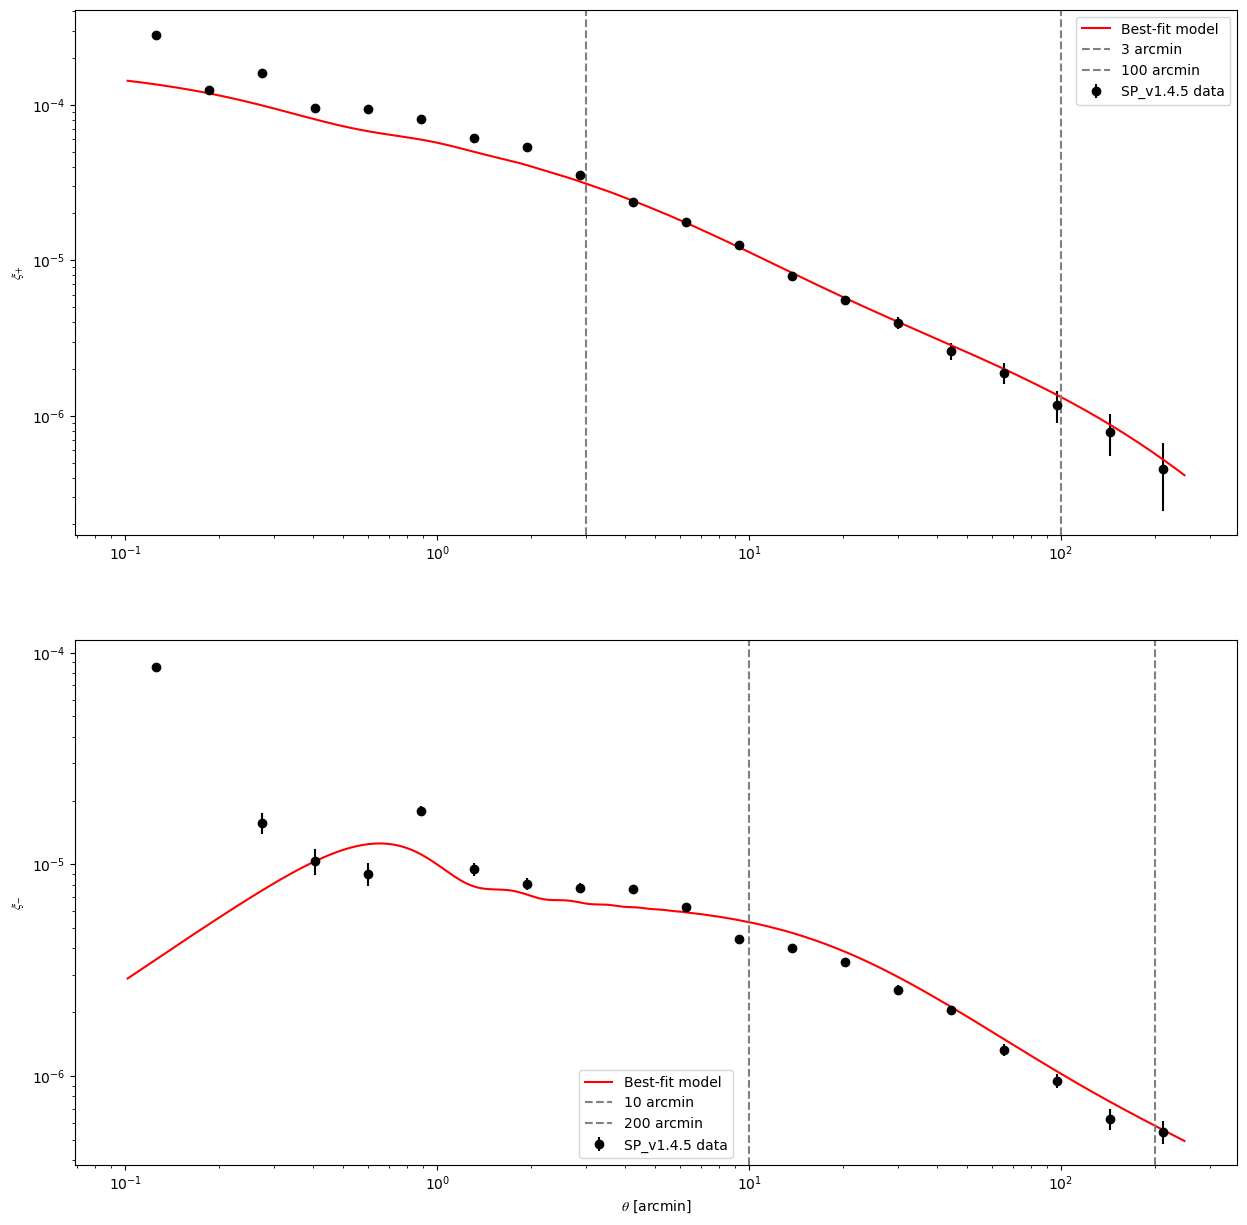

In [65]:
plt.figure(figsize=(15, 15))

plt.subplot(211)

plt.errorbar(xi_plus['ANG'], xi_plus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[:20], fmt='o', label='SP_v1.4.5 data', color='black')
plt.plot(angle[mask], xi_plus_bf[mask], label='Best-fit model', color='red')

plt.ylabel(r'$\xi_{+}$')
plt.xscale('log')
plt.yscale('log')
plt.axvline(3.0, color='grey', linestyle='--', label='3 arcmin')
plt.axvline(100.0, color='grey', linestyle='--', label='100 arcmin')
plt.legend()

plt.subplot(212)

plt.errorbar(xi_minus['ANG'], xi_minus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[20:40], fmt='o', label='SP_v1.4.5 data', color='black')
plt.plot(angle[mask], xi_minus_bf[mask], label='Best-fit model', color='red')

plt.xlabel(r'$\theta$ [arcmin]')
plt.ylabel(r'$\xi_{-}$')
plt.xscale('log')
plt.yscale('log')
plt.axvline(10.0, color='grey', linestyle='--', label='10 arcmin')
plt.axvline(200.0, color='grey', linestyle='--', label='200 arcmin')
plt.legend()

plt.savefig('xi_data_bf.png')
plt.show()

In [56]:
#Add PSF systematic
xi_sys_plus = np.loadtxt(root_dir+'/xi_sys/shear_xi_plus.txt')
xi_sys_minus = np.loadtxt(root_dir+'/xi_sys/shear_xi_minus.txt')
theta_sys = np.loadtxt(root_dir+'/xi_sys/theta.txt')
theta_sys = theta_sys * 180*60/np.pi

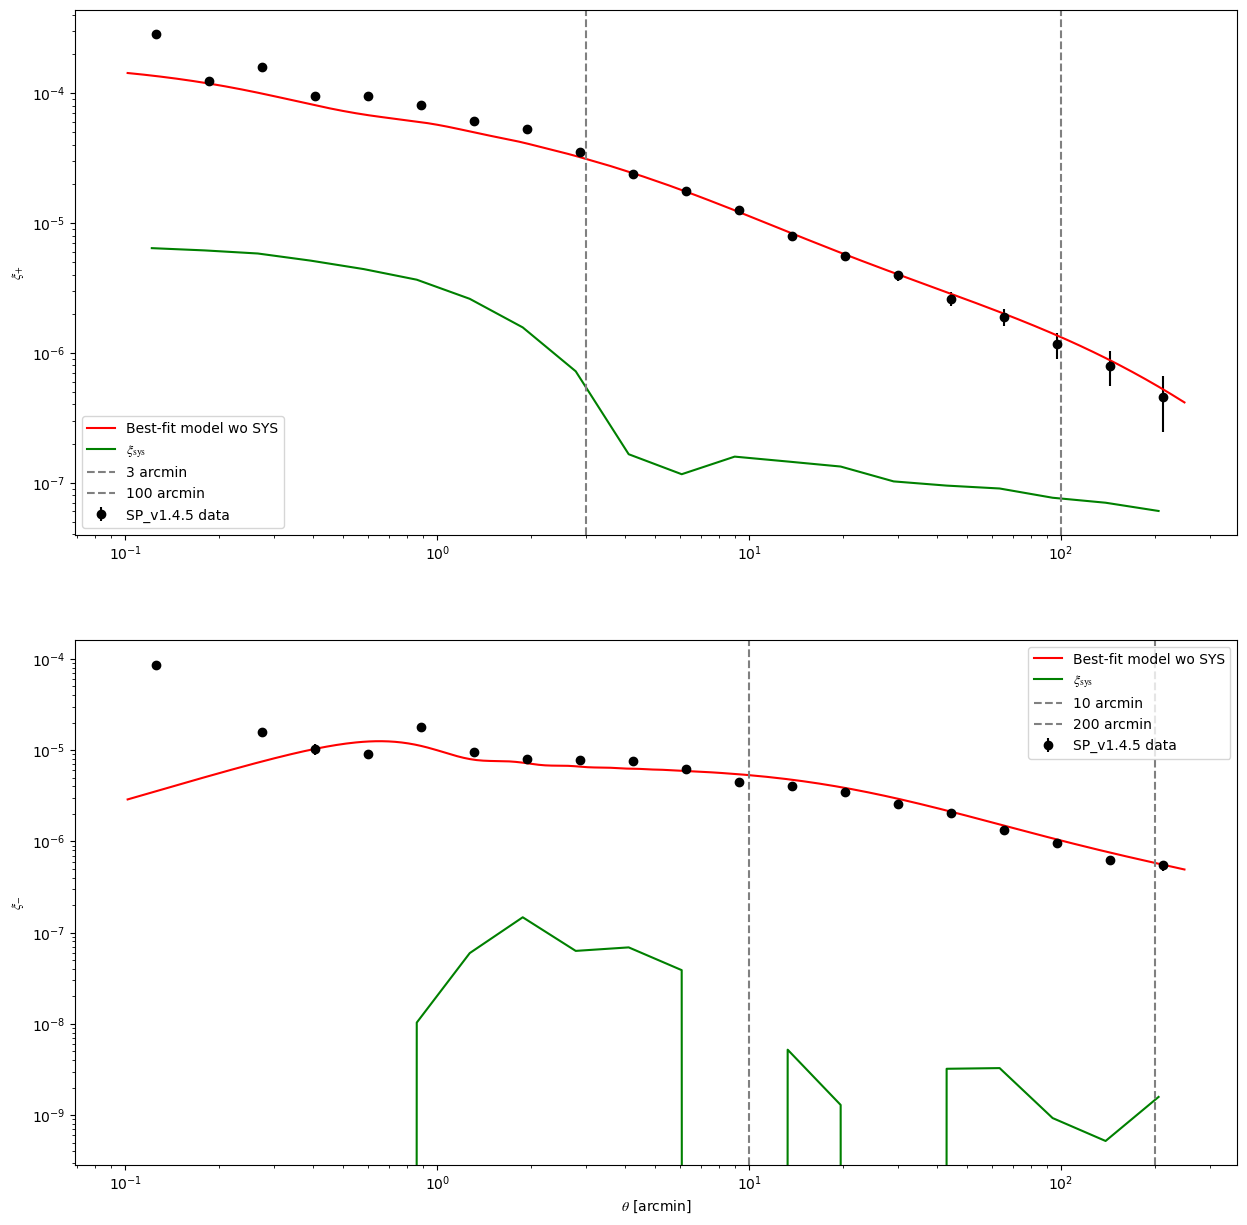

In [66]:
plt.figure(figsize=(15, 15))

plt.subplot(211)

plt.errorbar(xi_plus['ANG'], xi_plus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[:20], fmt='o', label='SP_v1.4.5 data', color='black')
plt.plot(angle[mask], xi_plus_bf[mask], label='Best-fit model wo SYS', color='red')
plt.plot(theta_sys, xi_sys_plus, label=r'$\xi_{\rm sys}$', color='green')

plt.ylabel(r'$\xi_{+}$')
plt.xscale('log')
plt.yscale('log')
plt.axvline(3.0, color='grey', linestyle='--', label='3 arcmin')
plt.axvline(100.0, color='grey', linestyle='--', label='100 arcmin')
plt.legend()

plt.subplot(212)

plt.errorbar(xi_minus['ANG'], xi_minus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[20:40], fmt='o', label='SP_v1.4.5 data', color='black')
plt.plot(angle[mask], xi_minus_bf[mask], label='Best-fit model wo SYS', color='red')
plt.plot(theta_sys, xi_sys_minus, label=r'$\xi_{\rm sys}$', color='green')

plt.xlabel(r'$\theta$ [arcmin]')
plt.ylabel(r'$\xi_{-}$')
plt.xscale('log')
plt.yscale('log')
plt.axvline(10.0, color='grey', linestyle='--', label='10 arcmin')
plt.axvline(200.0, color='grey', linestyle='--', label='200 arcmin')
plt.legend()

plt.savefig('xi_data_bf_sys.png')
plt.show()

In [58]:
shear_cl = np.loadtxt(root_dir+'/shear_cl/bin_1_1.txt')
shear_cl_gg = np.loadtxt(root_dir+'/shear_cl_gg/bin_1_1.txt')
shear_cl_gi = np.loadtxt(root_dir+'/shear_cl_gi/bin_1_1.txt')
shear_cl_ii = np.loadtxt(root_dir+'/shear_cl_ii/bin_1_1.txt')

In [59]:
A = 3.355083374185272
np.isclose(shear_cl, shear_cl_gg + 2*shear_cl_gi + shear_cl_ii)

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [61]:
#Add the lensing part without intrinsic alignment
root_dir = '/n09data/guerrini/output_chains/test_pipeline/'
xi_plus_wo_ia = np.loadtxt(root_dir+'/shear_xi_plus_wo_IA/bin_1_1.txt')
xi_minus_wo_ia = np.loadtxt(root_dir+'/shear_xi_minus_wo_IA/bin_1_1.txt')
angle = np.loadtxt(root_dir+'/shear_xi_plus_wo_IA/theta.txt')
angle = angle * 180*60/np.pi

mask = (angle < 250) & (angle > 0.1)

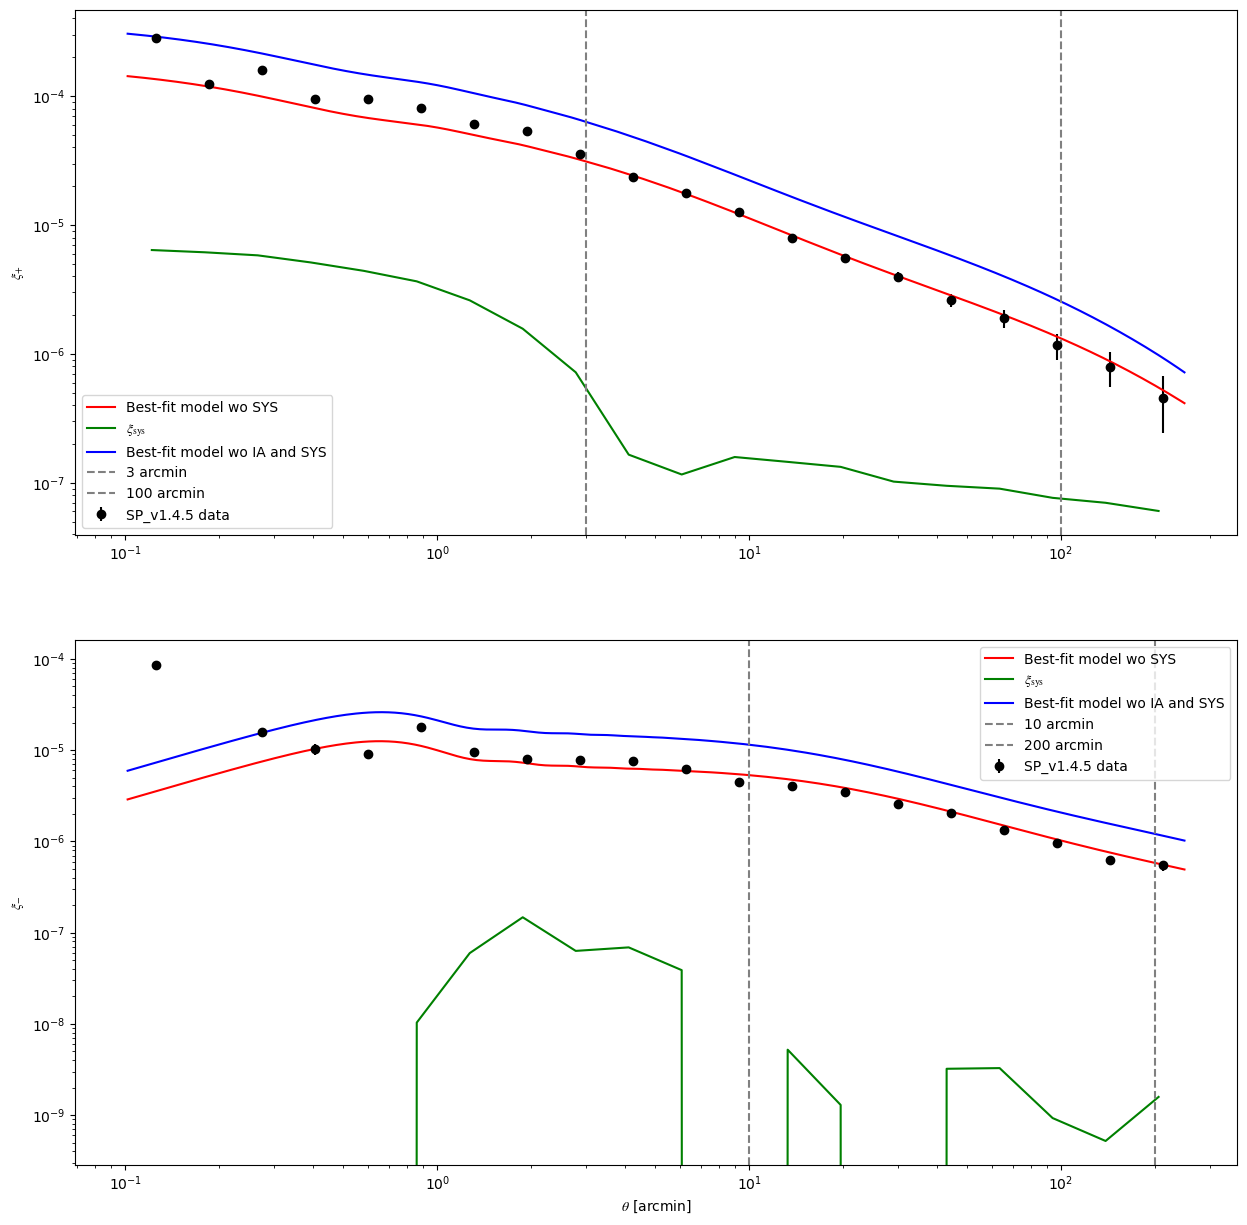

In [70]:
plt.figure(figsize=(15, 15))

plt.subplot(211)

plt.errorbar(xi_plus['ANG'], xi_plus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[:20], fmt='o', label='SP_v1.4.5 data', color='black')
plt.plot(angle[mask], xi_plus_bf[mask], label='Best-fit model wo SYS', color='red')
plt.plot(theta_sys, xi_sys_plus, label=r'$\xi_{\rm sys}$', color='green')
plt.plot(angle[mask], xi_plus_wo_ia[mask], label='Best-fit model wo IA and SYS', color='blue')

plt.ylabel(r'$\xi_{+}$')
plt.xscale('log')
plt.yscale('log')
plt.axvline(3.0, color='grey', linestyle='--', label='3 arcmin')
plt.axvline(100.0, color='grey', linestyle='--', label='100 arcmin')
plt.legend()

plt.subplot(212)

plt.errorbar(xi_minus['ANG'], xi_minus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[20:40], fmt='o', label='SP_v1.4.5 data', color='black')
plt.plot(angle[mask], xi_minus_bf[mask], label='Best-fit model wo SYS', color='red')
plt.plot(theta_sys, xi_sys_minus, label=r'$\xi_{\rm sys}$', color='green')
plt.plot(angle[mask], xi_minus_wo_ia[mask], label='Best-fit model wo IA and SYS', color='blue')

plt.xlabel(r'$\theta$ [arcmin]')
plt.ylabel(r'$\xi_{-}$')
plt.xscale('log')
plt.yscale('log')
plt.axvline(10.0, color='grey', linestyle='--', label='10 arcmin')
plt.axvline(200.0, color='grey', linestyle='--', label='200 arcmin')
plt.legend()

plt.savefig('xi_data_bf_sys_ia.png')
plt.show()

In [68]:
#Add the lensing part without intrinsic alignment
root_dir = '/n09data/guerrini/output_chains/test_pipeline/'
xi_plus_reas = np.loadtxt(root_dir+'/shear_xi_plus/bin_1_1.txt')
xi_minus_reas = np.loadtxt(root_dir+'/shear_xi_minus/bin_1_1.txt')
angle_reas = np.loadtxt(root_dir+'/shear_xi_plus/theta.txt')
angle_reas = angle_reas * 180*60/np.pi

mask = (angle < 250) & (angle > 0.1)

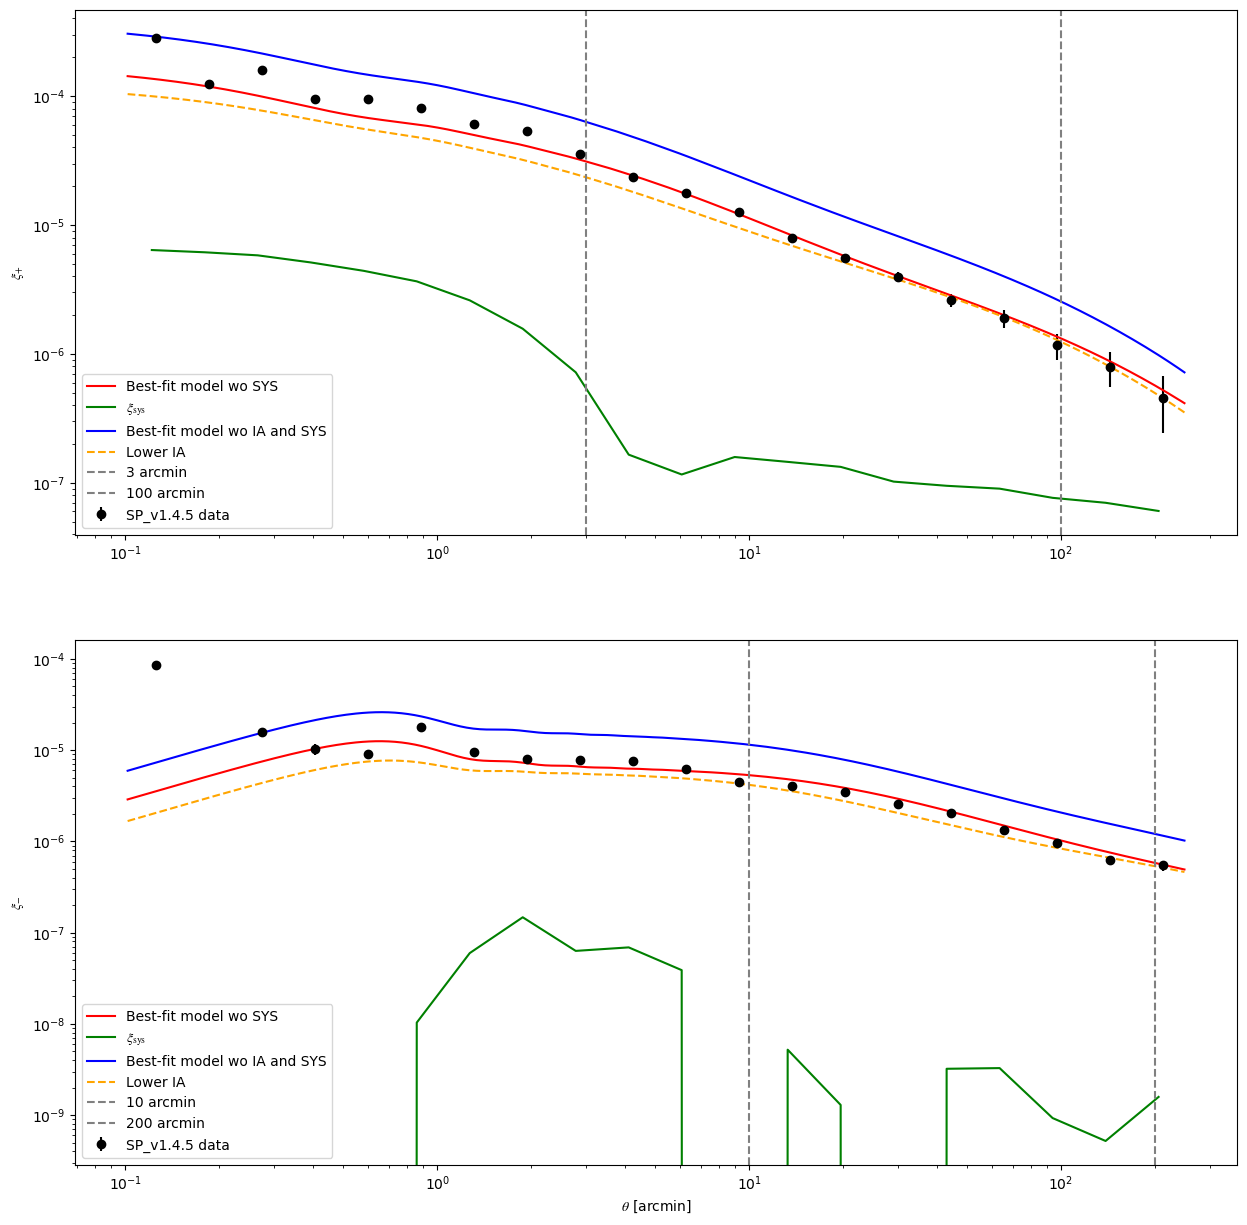

In [71]:
plt.figure(figsize=(15, 15))

plt.subplot(211)

plt.errorbar(xi_plus['ANG'], xi_plus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[:20], fmt='o', label='SP_v1.4.5 data', color='black')
plt.plot(angle[mask], xi_plus_bf[mask], label='Best-fit model wo SYS', color='red')
plt.plot(theta_sys, xi_sys_plus, label=r'$\xi_{\rm sys}$', color='green')
plt.plot(angle[mask], xi_plus_wo_ia[mask], label='Best-fit model wo IA and SYS', color='blue')
plt.plot(angle_reas[mask], xi_plus_reas[mask], label='Lower IA', color='orange', linestyle='--')

plt.ylabel(r'$\xi_{+}$')
plt.xscale('log')
plt.yscale('log')
plt.axvline(3.0, color='grey', linestyle='--', label='3 arcmin')
plt.axvline(100.0, color='grey', linestyle='--', label='100 arcmin')
plt.legend()

plt.subplot(212)

plt.errorbar(xi_minus['ANG'], xi_minus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[20:40], fmt='o', label='SP_v1.4.5 data', color='black')
plt.plot(angle[mask], xi_minus_bf[mask], label='Best-fit model wo SYS', color='red')
plt.plot(theta_sys, xi_sys_minus, label=r'$\xi_{\rm sys}$', color='green')
plt.plot(angle[mask], xi_minus_wo_ia[mask], label='Best-fit model wo IA and SYS', color='blue')
plt.plot(angle_reas[mask], xi_minus_reas[mask], label='Lower IA', color='orange', linestyle='--')

plt.xlabel(r'$\theta$ [arcmin]')
plt.ylabel(r'$\xi_{-}$')
plt.xscale('log')
plt.yscale('log')
plt.axvline(10.0, color='grey', linestyle='--', label='10 arcmin')
plt.axvline(200.0, color='grey', linestyle='--', label='200 arcmin')
plt.legend()

plt.savefig('xi_data_bf_sys_ia_reas.png')
plt.show()